In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score

In [2]:
!pip install xgboost
import xgboost as xgb

from  xgboost import XGBRegressor

In [3]:
housing = fetch_california_housing()
print(housing.DESCR)
print(housing.target.shape)


.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

    :Number of Instances: 20640

    :Number of Attributes: 8 numeric, predictive attributes and the target

    :Attribute Information:
        - MedInc        median income in block group
        - HouseAge      median house age in block group
        - AveRooms      average number of rooms per household
        - AveBedrms     average number of bedrooms per household
        - Population    block group population
        - AveOccup      average number of household members
        - Latitude      block group latitude
        - Longitude     block group longitude

    :Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived

In [4]:
x_df = pd.DataFrame(housing.data,columns=housing.feature_names)
x_df.head()
y_df = pd.DataFrame(housing.target,columns= ['target'])
print(y_df.describe)
y_df.head()

<bound method NDFrame.describe of        target
0       4.526
1       3.585
2       3.521
3       3.413
4       3.422
...       ...
20635   0.781
20636   0.771
20637   0.923
20638   0.847
20639   0.894

[20640 rows x 1 columns]>


,target
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422


In [5]:
x_train,x_test,y_train,y_test = train_test_split(housing.data,housing.target,
                                                 test_size=0.25,
                                                  random_state=11)
x_train.shape
x_test.shape

(5160, 8)

In [6]:
xgb_model= XGBRegressor( objective='reg:squarederror',n_estimators= 100,
                        learning_rate = 0.1,max_depth = 6, random_state =
                        11,verbosity= 0)
xgb_model.fit(x_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [7]:
xgb_early = XGBRegressor(objective = 'reg:squarederror',
                         n_estimators=1000,
                         learning_rate=0.1,
                         max_depth =6,
                         random_state = 11,
                         verbosity = 0,
                        early_stopping_rounds=50
                        )

xgb_early.fit(x_train,
              y_train,
              eval_set= [(x_test,y_test)],
              verbose = False
             )
print(f"best iteration: {xgb_early.best_iteration}")
print(f"best score: {xgb_early.score(x_test,y_test):.4f}")


best iteration: 508
best score: 0.8451


In [8]:
predicted = xgb_model.predict(x_test)
expected = y_test
print(f"predicted: {predicted[:10]}")
print(f"actual: {expected[:10]}")


predicted: [1.0305979 2.0478652 2.9240286 1.9770259 2.020336  2.0379195 1.8024547
 2.4052172 2.2651355 1.004055 ]
actual: [0.762 1.732 1.125 1.37  1.856 2.393 1.214 2.389 1.663 1.063]


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


<function matplotlib.pyplot.show(close=None, block=None)>

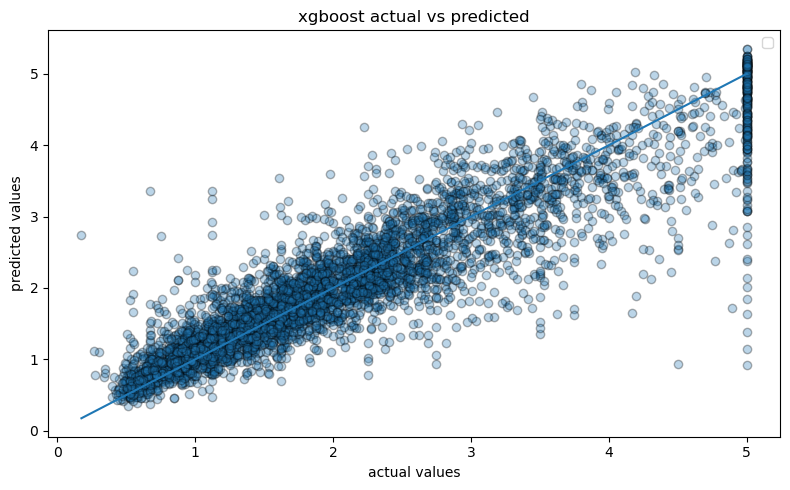

In [9]:
plt.figure(figsize = (8,5))
plt.scatter(expected,predicted,alpha= 0.3,edgecolors='k')
plt.plot([expected.min(),expected.max()],[expected.min(),expected.max()]
        )
plt.xlabel('actual values')
plt.ylabel('predicted values')
plt.title('xgboost actual vs predicted')
plt.legend()
plt.tight_layout()
plt.show
           

In [10]:
print(f"R2 score: {r2_score(expected,predicted):.4f}")
print(f"Mean Absolute error score: {mean_absolute_error(expected,predicted):.4f}")
print(f"Mean squared error score: {mean_squared_error(expected,predicted):.4f}")
print(f" RMSE: {np.sqrt(mean_squared_error(expected,predicted)):.4f}")

R2 score: 0.8284
Mean Absolute error score: 0.3190
Mean squared error score: 0.2300
 RMSE: 0.4796


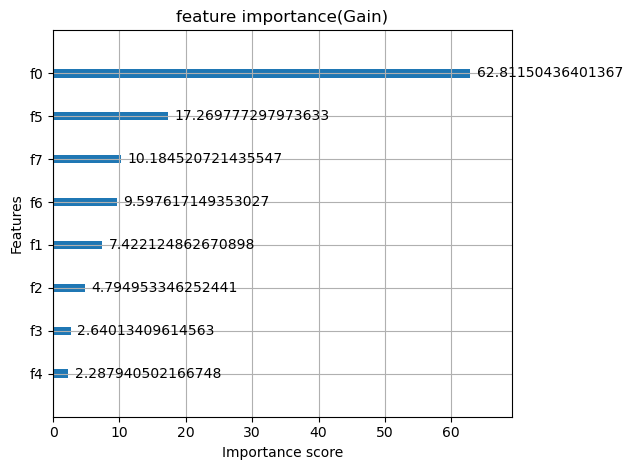

In [11]:
xgb.plot_importance(xgb_model,
                    importance_type ='gain',
                    title='feature importance(Gain)'
                   )
plt.tight_layout()
plt.show()

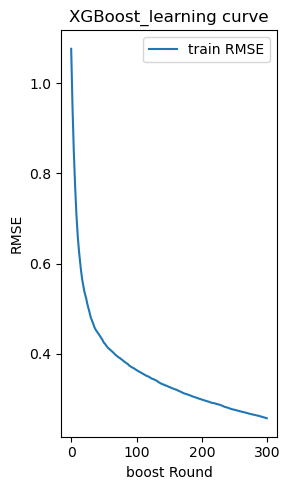

In [12]:
xgb_eval = XGBRegressor(objective = 'reg:squarederror',
                         n_estimators=300,
                         learning_rate=0.1,
                         max_depth =6,
                         random_state = 11,
                         verbosity = 0
                       )
eval_results = {}
xgb_eval.fit(x_train,y_train,
             eval_set=[(x_train,y_train),(x_test,y_test)],
             verbose = False)
results = xgb_eval.evals_result()
train_rmse = results['validation_0']['rmse']
test_rmse = results['validation_1']['rmse']

plt.figure(figsize = (3,5))
plt.plot(train_rmse,label ='train RMSE')
plt.xlabel('boost Round')
plt.ylabel('RMSE')
plt.title('XGBoost_learning curve')
plt.legend()
plt.tight_layout()
plt.show()



                        
    

In [13]:
from sklearn.model_selection import GridSearchCV
param_grid ={
    'n_estimators':[100,200],
    'learning_rate':[0.1,0.3],
     'max_depth':[3,6],
    'subsample':[0.7,0.8,1.0],
    'colsample_bytree':[0.7,0.8,1.0],
    'gamma':[0,0.1]
}
grid= GridSearchCV(XGBRegressor(objective = 'reg:squarederror',
                                random_state= 11,
                                verbosity=0),
                   param_grid,cv=5,scoring='r2',
                   n_jobs = -1
                  )
grid.fit(x_train,y_train)
print("Starting GridSearchCV...")


                   
    

Starting GridSearchCV...


In [14]:
print(f"best parameter:{grid.best_params_}")
print(f"best :{grid.best_params_}")


best parameter:{'colsample_bytree': 0.8, 'gamma': 0.1, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}
best :{'colsample_bytree': 0.8, 'gamma': 0.1, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}


In [15]:
best_xgb= grid.best_estimator_
predicted_best= best_xgb.predict(x_test)

In [16]:
print(f" best predicted :{predicted_best[0:10]}")
print(f"actual:{expected[0:10]}")
print(f"test r2 with best model:{r2_score(expected,predicted_best):.4f}")

 best predicted :[0.91505486 2.0314443  2.686813   1.9283808  2.3247576  2.4821136
 1.9161596  2.1191676  2.1066463  0.99595547]
actual:[0.762 1.732 1.125 1.37  1.856 2.393 1.214 2.389 1.663 1.063]
test r2 with best model:0.8403


In [17]:
best_xgb.save_model('xgb_model.json')